# Federated Learning: Training Models on Distributed Data

## Overview
Federated Learning is a machine learning technique that trains models across multiple decentralized devices or servers holding local data samples, without exchanging them. This approach:
- Preserves data privacy
- Reduces data transfer requirements
- Allows training on heterogeneous data distributions

In this notebook, we simulate federated learning by splitting the MNIST dataset into three parts with different digit distributions, training separate models on each, and evaluating their performance.


In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader, random_split
from torchvision import datasets, transforms


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#### Import the MNIST dataset
* Load the MNIST dataset using the `datasets.MNIST` function.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.MNIST(
    "./MNIST_data/", download=True, train=True, transform=transform
)

100.0%
100.0%
100.0%
100.0%


### Split the training dataset to three datasets for this example.
* Set the three different datasets, excluding some digits as shown in the explanation.
    - `part1` excludes digits 1, 3, and 7.
    - `part2` excludes digits 2, 5, and 8.
    - `part3` excludes digits 4, 6, and 9.

This simulates the different datasets that might be available in real world (datasets with missing data, extra data, etc).

In [3]:
total_length = len(trainset)
split_size = total_length // 3
torch.manual_seed(42)
part1, part2, part3 = random_split(trainset, [split_size] * 3)

In [15]:
def include_digits(dataset, included_digits):
    including_indices = [
        idx for idx in range(len(dataset)) if dataset[idx][1] in included_digits
    ]
    return torch.utils.data.Subset(dataset, including_indices)

def exclude_digits(dataset, excluded_digits):
    including_indices = [
        idx for idx in range(len(dataset)) if dataset[idx][1] not in excluded_digits
    ]
    return torch.utils.data.Subset(dataset, including_indcies)

In [5]:
part1 = exclude_digits(part1, excluded_digits=[1, 3, 7])
part2 = exclude_digits(part2, excluded_digits=[2, 5, 8])
part3 = exclude_digits(part3, excluded_digits=[4, 6, 9])

### Plot the three datasets.

In [6]:
def plot_distribution(dataset, title):
    labels = [data[1] for data in dataset]
    unique_labels, label_counts = torch.unique(torch.tensor(labels), return_counts=True)
    plt.figure(figsize=(4, 3))

    counts_dict = {
        label.item(): count.item() for label, count in zip(unique_labels, label_counts)
    }
    all_labels = np.arange(10)
    all_label_counts = [counts_dict.get(label, 0) for label in all_labels]

    plt.bar(all_labels, all_label_counts)
    plt.title(title)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.xticks(all_labels)
    plt.show()

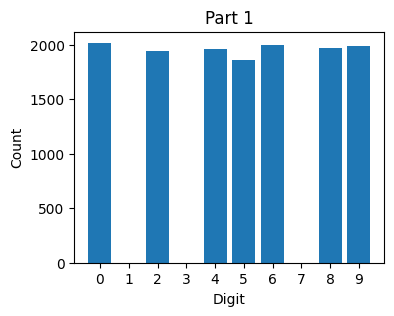

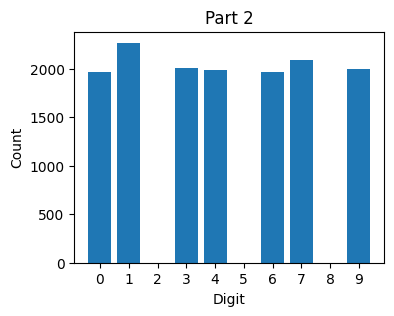

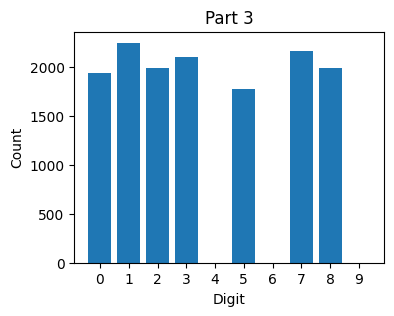

In [7]:
plot_distribution(part1, "Part 1")
plot_distribution(part2, "Part 2")
plot_distribution(part3, "Part 3")

### Model Architecture
We define a simple fully connected neural network with:
- Input layer: 784 neurons (flattened 28x28 MNIST images)
- Hidden layer: 128 neurons with ReLU activation
- Output layer: 10 neurons (one for each digit class)

This simple architecture allows us to quickly demonstrate the federated learning concept without extensive computational requirements.


In [10]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = self.relu(x)
        x = self.out(x)
        return x

def train_model(model, train_set):
    batch_size = 64
    num_epochs = 10
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}: Loss = {running_loss / len(train_loader)}")
    print("===== Training completed =====")

### Define three and run the models.

Three instances of the `SimpleModel` class (`model1`, `model2`, `model3`) are created for training.

In [11]:
model1 = SimpleModel()
train_model(model1, part1)

model2 = SimpleModel()
train_model(model2, part2)

model3 = SimpleModel()
train_model(model3, part3)

Epoch 1: Loss = 0.51204928502787
Epoch 2: Loss = 0.23714013584824495
Epoch 3: Loss = 0.19103869116583536
Epoch 4: Loss = 0.16711511452530706
Epoch 5: Loss = 0.13221901786015477
Epoch 6: Loss = 0.11425640943438507
Epoch 7: Loss = 0.0971962371061361
Epoch 8: Loss = 0.08240503151576187
Epoch 9: Loss = 0.07416755696975215
Epoch 10: Loss = 0.06360028057770674
Training completed
Epoch 1: Loss = 0.4040545738535002
Epoch 2: Loss = 0.1840380184418921
Epoch 3: Loss = 0.15680130280088633
Epoch 4: Loss = 0.12872988277480804
Epoch 5: Loss = 0.11090067389055289
Epoch 6: Loss = 0.09778876742348075
Epoch 7: Loss = 0.08733287009610129
Epoch 8: Loss = 0.07760503421221594
Epoch 9: Loss = 0.07234199944650754
Epoch 10: Loss = 0.06355240929510078
Training completed
Epoch 1: Loss = 0.4877803710935352
Epoch 2: Loss = 0.2588299443391529
Epoch 3: Loss = 0.18997077482777672
Epoch 4: Loss = 0.15642433392034993
Epoch 5: Loss = 0.13117204187018378
Epoch 6: Loss = 0.1083615911738561
Epoch 7: Loss = 0.092608674966335

### Evaluation Strategy
To properly evaluate how well each model performs on the digits it was NOT trained on, we:
1. Test each model on the complete test dataset (all 10 digits)
2. Test each model on specific digit subsets that were excluded from their training

This helps us understand:
- How well models generalize to unseen digit classes
- The limitations of training on non-IID (non-independent and identically distributed) data
- Why federated learning requires special aggregation techniques


In [12]:
testset = datasets.MNIST(
    "./MNIST_data/", download=True, train=False, transform=transform
)

* Dataset preparation:
   - `testset_137` includes digits 1, 3, and 7.
   - `testset_258` includes digits 2, 5, and 8.
   - `testset_469` includes digits 4, 6, and 9.

In [16]:
testset_137 = include_digits(testset, included_digits=[1, 3, 7])
testset_258 = include_digits(testset, included_digits=[2, 5, 8])
testset_469 = include_digits(testset, included_digits=[4, 6, 9])

In [19]:
def evaluate_model(model, test_set):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss = criterion(outputs, labels)
            total_loss += loss.item()
    accuracy = correct / loss
    average_loss = total_loss / len(test_loader)
    return average_loss, accuracy

### Evaluate the models with the test datasets.

The `evaluate_model` function is called to evaluate each model defined above (`model1`, `model2`, `model3`) on both, the entire test dataset and specific subsets of the test dataset.

In [20]:
_, accuracy1 = evaluate_model(model1, testset)
_, accuracy1_on_137 = evaluate_model(model1, testset_137)
print(
    f"Model 1-> Test Accuracy on all digits: {accuracy1:.4f}, "
    f"Test Accuracy on [1,3,7]: {accuracy1_on_137:.4f}"
)

_, accuracy2 = evaluate_model(model2, testset)
_, accuracy2_on_258 = evaluate_model(model2, testset_258)
print(
    f"Model 2-> Test Accuracy on all digits: {accuracy2:.4f}, "
    f"Test Accuracy on [2,5,8]: {accuracy2_on_258:.4f}"
)

_, accuracy3 = evaluate_model(model3, testset)
_, accuracy3_on_469 = evaluate_model(model3, testset_469)
print(
    f"Model 3-> Test Accuracy on all digits: {accuracy3:.4f}, "
    f"Test Accuracy on [4,6,9]: {accuracy3_on_469:.4f}"
)

Model 1-> Test Accuracy on all digits: 1586.1584, Test Accuracy on [1,3,7]: 0.0000
Model 2-> Test Accuracy on all digits: 1799.5465, Test Accuracy on [2,5,8]: 0.0000
Model 3-> Test Accuracy on all digits: 1755.0806, Test Accuracy on [4,6,9]: 0.0000


### Key Observations
From the accuracy results above, you should notice:
- Each model performs well on digits it was trained on
- Each model performs poorly on digits it never saw during training
- This demonstrates the **non-IID data problem** in federated learning

This is why federated learning algorithms like **FedAvg** (Federated Averaging) are needed - to aggregate model weights from multiple clients and create a global model that performs well on all classes.


A confusion matrix is a table that is used to evaluate the performance of a classification model. It shows:
- **True Positives (TP)**: Correctly predicted positive class
- **True Negatives (TN)**: Correctly predicted negative class  
- **False Positives (FP)**: Incorrectly predicted positive class (Type I error)
- **False Negatives (FN)**: Incorrectly predicted negative class (Type II error)

The diagonal elements represent correct predictions, while off-diagonal elements represent misclassifications. This helps us understand which digits each model confuses.


In [23]:
def compute_confusion_matrix(model, testset):
    true_labels = []
    predicted_labels = []

    for image, label in testset:
        output = model(image.unsqueeze(0)) # Add the batch dimension
        _, predicted = torch.max(output, 1)

        true_labels.append(label)
        predicted_labels.append(predicted.item())

    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    cm = confusion_matrix(true_labels, predicted_labels)
    return cm


def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=0.5)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

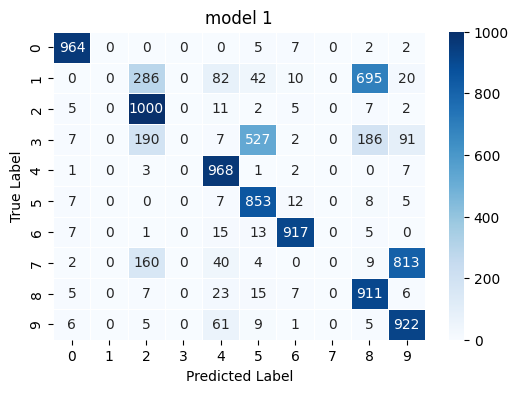

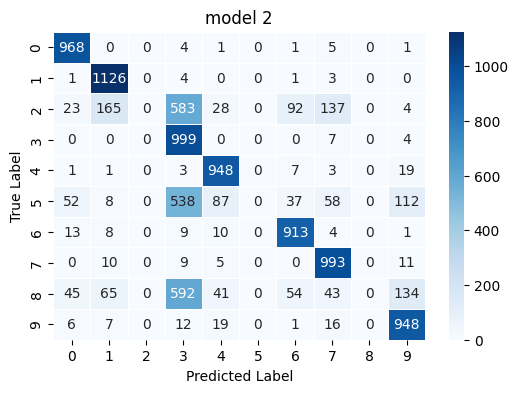

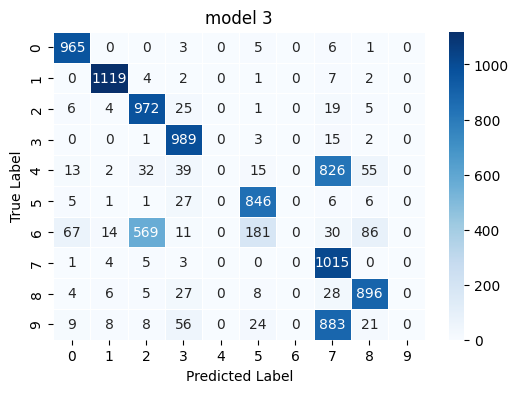

In [24]:
confusion_matrix_model1_all = compute_confusion_matrix(model1, testset)
confusion_matrix_model2_all = compute_confusion_matrix(model2, testset)
confusion_matrix_model3_all = compute_confusion_matrix(model3, testset)

plot_confusion_matrix(confusion_matrix_model1_all, "model 1")
plot_confusion_matrix(confusion_matrix_model2_all, "model 2")
plot_confusion_matrix(confusion_matrix_model3_all, "model 3")